# `gwtf` quickstart

This notebook contains a minimal example for generating waveforms or inner products in the time-frequency domain with `gwtf`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT2Ecc

In [2]:
dT = 86400 / 4  # 6 hours
nT = 365 * 4  # 1 year
dt = 5
dF = 1 / dT
nF = int(1 / (2 * dF) / dt) + 1

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 100,  # number of frequency bins to use in the fresnel kernel
}

First, let's look at the transverse-traceless polarisations. This is set by passing `tdi_type=None` (the default).

In [3]:
generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=None,
)

We can generate waveforms by calling the generator.

In [4]:
generator.model.parameters

['M', 'eta', 'cosi', 'e0', 'D', 'f0', 'phi_coal']

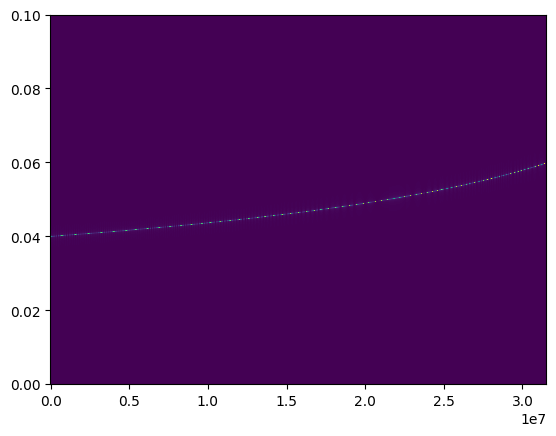

In [5]:
pars = {
    "M": 30,
    "eta": 0.25,
    "cosi": 0.5,
    "e0": 1e-3,
    "D": 1e3,
    "f0": 4e-2,
    "phi_coal": 0.1,
}

tf = generator(pars)

plt.pcolormesh(generator.t_tranche, generator.f_tranche, np.abs(tf[:, :, 0].T))

Waveforms for multiple sources can be generated by passing 1-d arrays. We'll add the results together for plotting:

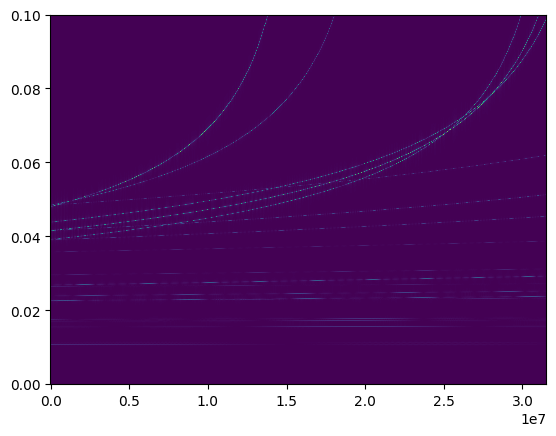

In [ ]:
rng = np.random.default_rng(1729)
pars = {
    "M": rng.uniform(20, 50, size=20),
    "eta": rng.uniform(0.1, 0.25, size=20),
    "cosi": rng.uniform(0, 1, size=20),
    "e0": rng.uniform(1e-4, 1e-2, size=20),
    "D": rng.uniform(1e3, 1e3, size=20),
    "f0": rng.uniform(1e-2, 5e-2, size=20),
    "phi_coal": rng.uniform(0, 1, size=20),
}

tf = generator(pars).sum(0)

plt.pcolormesh(generator.t_tranche, generator.f_tranche, np.abs(tf[:, :, 0].T))

We can also construct the complex inner product over tranches. Let's demonstrate for those signals (assuming a flat PSD for now). Note that the returned inner products $\langle d \mid h \rangle$ and $\langle h \mid h \rangle$ will be essentially equal here as no noise is present:

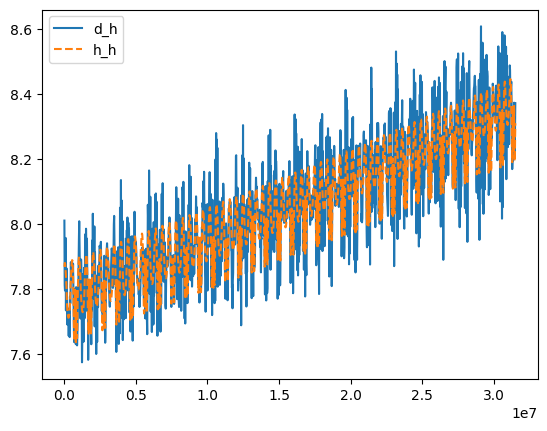

In [25]:
rng = np.random.default_rng(1729)
pars_stat = pars.copy()
tf_stat = generator(
    pars_stat,
    channels=tf,
    psds=np.ones_like(tf) * 1e-34,
    compute_statistic=True,
)

plt.plot(generator.t_tranche, np.abs(tf_stat[0, :, 0]), label="d_h")
plt.plot(generator.t_tranche, np.abs(tf_stat[0, :, 1]), ls="--", label="h_h")
plt.legend()

## TDI generation

We can also generate TDI variables. Right now it just generates the AET channels. You can choose the TDI generation and the spacecraft orbit information (passed as an array of shape `(nT, 3, 3)`). The latter falls back on Keplerian analytic orbits if not provided.

In [26]:
tdi_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
)

Spacecraft orbits not supplied. Falling back to analytic orbits


We also have to pass response parameters here. Clunky rn and needs updated to be more flexible / clear

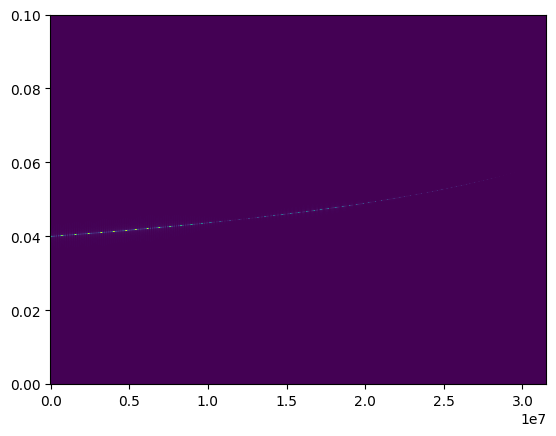

In [ ]:
pars = {
    "M": 30,
    "eta": 0.25,
    "cosi": 0.5,
    "e0": 1e-3,
    "D": 1e3,
    "f0": 4e-2,
    "phi_coal": 0.1,
}

parameters_response = np.array(
    [
        [
            pars["cosi"],
            np.pi / 6,  # pol
            5 * np.pi / 4,  # ecliptic longitude
            np.pi / 3,  # ecliptic latitude
        ]
    ]
)

tf_tdi = tdi_generator(pars, parameters_response=parameters_response)

plt.pcolormesh(
    generator.t_tranche, generator.f_tranche, np.abs(tf_tdi[:, :, 0].T)
)

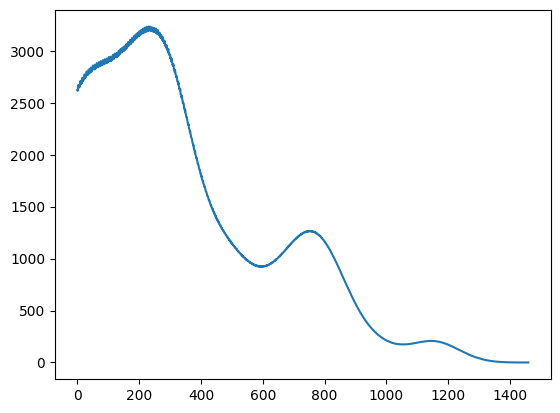

In [56]:
tf_tdi_stat = tdi_generator(
    pars,
    channels=tf_tdi,
    psds=np.ones_like(tf) * 1e-34,
    parameters_response=parameters_response,
    compute_statistic=True,
)

plt.plot(tf_tdi_stat[:, 0].real)